## Time-frequency analysis

Here, we demonstrate the usage of methods in `mmspy.computation.time_frequency` for analysis of time series data in time-frequency domain with Fourier and wavelet transforms. We will use the July 2017 turbulent magnetotail reconnection event discussed by [Ergun, R. E., Ahmadi, N., Kromyda, L., et al. 2020, ApJ, 898, 154](https://doi.org/10.3847/1538-4357/ab9ab6). Below is an excerpt of their Figure 1 showing the event overview:
![Ergun+20 event overview](../_static/examples/time-frequency-analysis/ergun+20_overview.png)

The turbulent magnetic field in panel (e) between 07:20 and 07:40 has the following spectrum (extracted from Figure 3).

![Ergun+20 spectrum](../_static/examples/time-frequency-analysis/ergun+20_spectrum.png)

### Load data

We shall reproduce the above spectral calculations. But first, let us sync the fluxgate magnetometer data for this event from MMS FGM instrument:

In [1]:
import xarray as xr
import numpy as np
import mmspy

mms = mmspy.api.MMS()
fgm = mms.load_dataset(
    start_date="2017-07-26T07:20",
    end_date="2017-07-26T07:40",
    probe="mms2",
    instrument="fgm",
    data_type="bfield",
    data_rate="brst",
)


24-Dec-02 16:49:34 [INFO]: Using Python-MIP package version 1.16rc0
24-Dec-02 16:49:35 [WARNING]: /home/tvo/.local/share/mamba/envs/mmspy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

                                                                                                       24-Dec-02 16:49:36 [INFO]: mms2_fgm_brst_l2_20170726073713_v5.98.0.cdf is up-to-date.
                                                                                                       24-Dec-02 16:49:36 [INFO]: mms2_fgm_brst_l2_20170726073613_v5.98.0.cdf is up-to-date.
                                                                                                           24-Dec-02 16:49:36 [INFO]: mms2_fgm_brst_l2_20170726073213_v5.98.0.cdf is up-to-date.
                                                        

#### Examine data

In [2]:
Bx = fgm.B_gse.rank_1.component("x")
By = fgm.B_gse.rank_1.component("y")
Bz = fgm.B_gse.rank_1.component("z")
fgm

<xarray.Dataset> Size: 11MB
Dimensions:       (time: 134016, space_rank_1: 3)
Coordinates:
  * space_rank_1  (space_rank_1) <U3 36B 'x' 'y' 'z'
  * time          (time) datetime64[ns] 1MB 2017-07-26T07:21:13.448632770 ......
Data variables:
    B_gse         (time, space_rank_1) float32 2MB [nT] dask.array<concatenat...
    B_gsm         (time, space_rank_1) float32 2MB [nT] dask.array<concatenat...
    R_gse         (time, space_rank_1) float64 3MB [km] dask.array<concatenat...
    R_gsm         (time, space_rank_1) float64 3MB [km] dask.array<concatenat...
    flag          (time) uint32 536kB [] dask.array<concatenate, shape=(13401...
Attributes: (12/28)
    Data_type:                   brst_l2
    Data_version:                5.98.0
    Descriptor:                  FGM>Flux Gate Magnetometer
    Discipline:                  Space Physics>Magnetospheric Science
    File_naming_convention:      source_descriptor_datatype_yyyyMMddHHmmss
    Generated_by:                UCLA
    ...                          ...
    TEXT:                        ['The Fluxgate Magnetometers (FGM) on Magnet...
    Time_resolution:             0.0078125 sec
    end_date:                    2017-07-26T07:26:13.444180421
    probe:                       mms2
    source:                      mms2_fgm_brst_l2_20170726072113_v5.98.0.cdf
    start_date:                  2017-07-26T07:21:13.448632770

`mmspy.computation.time_frequency` provides a few functions for time-frequency analysis:

- `fft` calculates the Fourier spectrum for the entire signal, assuming time-stationarity;
- `stft` calculates the Fourier spectrum for a sliding window;
- `cwt` calculates the continuous wavelet spectrum for a given signal.

The above functions accept `numpy.ndarray` data structures. The module also provides corresponding wrappers that accept `xarray` data structures, i.e., `xr_fft`, `xr_stft`, and `xr_cwt`. In addition, there are also inverse transforms: `icwt` and `xr_icwt` calculate the inverse continuous wavelet transform of spectra derived from `cwt` and `xr_cwt`.

Let us demonstrate the usage of these functions below.

#### Fourier transform

`fft` and `xr_fft` provide one-sided Fourier spectra of two types: positive and negative frequencies. In addition, the normalization can either be 'spectrum' ($1$) or 'density' ($1/\sqrt{f}$):

In [3]:
from mmspy.computation.time_frequency import xr_fft

# Full-signal PSD
Sx_fft = xr_fft(Bx, normalization="density")
Sy_fft = xr_fft(By, normalization="density")
Sz_fft = xr_fft(Bz, normalization="density")
Sx_fft

Magnitude,[[ 6.51139574e+01-3.27075240e+01j -3.63154358e+01+4.28033748e-01j -9.04136356e+00+1.58849620e+01j ... 6.12971577e-05-3.64254369e-04j 1.88936860e-04+2.85241917e-04j -7.25398980e-05-8.50722814e-05j] [ 6.51139574e+01+3.27075240e+01j -3.63154358e+01-4.28033748e-01j -9.04136356e+00-1.58849620e+01j ... 6.12971577e-05+3.64254369e-04j 1.88936860e-04-2.85241917e-04j -7.25398980e-05+8.50722814e-05j]]
Units,nanotesla/hertz0.5


The total spectrum density is defined as:

In [4]:
S_fft = (np.abs(Sx_fft)**2 + np.abs(Sy_fft)**2 + np.abs(Sz_fft)**2).sum("type")
S_fft

Magnitude,[13017.87703899794 4317.18265276344 1175.8054887306275 ... 6.528020188093318e-07 4.82299425779435e-07 2.4150987518103664e-07]
Units,nanotesla2/hertz


Let us confirm the scaling of the total spectrum:

24-Dec-02 16:49:36 [INFO]: Using tvolib stylesheet
24-Dec-02 16:49:36 [WARNING]: /home/tvo/.local/share/mamba/envs/mmspy/lib/python3.12/site-packages/xarray/core/variable.py:352: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)



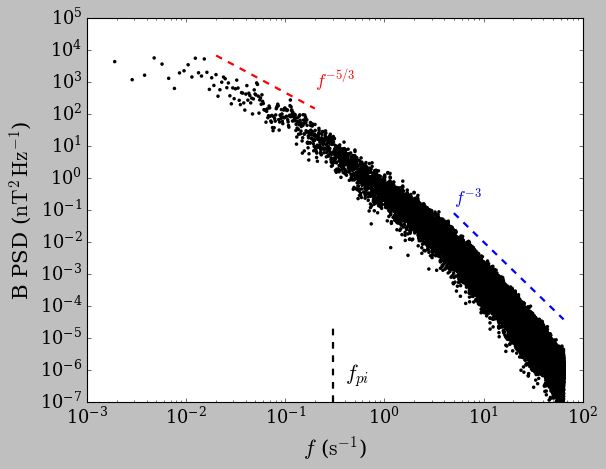

In [5]:
from tvolib import matplotlib_utils as mu

f_arr = np.logspace(
    np.log10(S_fft.frequency.values[0]),
    np.log10(S_fft.frequency.values[-1]),
    1000,
)

fig, ax = mu.plt.subplots(1, 1)

ax.scatter(S_fft.frequency, S_fft, fc="k", ec="none", s=10)

mask = (2e-2 <= f_arr) & (f_arr <= 2e-1)
ax.plot(x := f_arr[mask], y := 1e1 * f_arr[mask] ** (-5 / 3), "--r", lw=2)
ax.text(x[-1], 5 * y[-1], "$f^{-5/3}$", c="r")

mask = f_arr >= 5e0
ax.plot(x := f_arr[mask], y := 1e1 * f_arr[mask] ** (-3), "--b", lw=2)
ax.text(x[0], 2 * y[0], "$f^{-3}$", c="b")

ax.axvline(3e-1, ymin=0, ymax=0.2, ls="--", c="k", lw=2)
ax.text(4e-1, 5e-7, "$f_{pi}$", fontsize="large")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e2)
ax.set_ylim(1e-7, 1e5)
ax.set_xlabel(f"$f$ ({S_fft.frequency.units:latex})")
ax.set_ylabel(f"B PSD ({S_fft.pint.units:latex})")

mu.plt.show()

#### Short-time Fourier transform

`stft` and `xr_stft` provide the running two-sided Fourier spectra. Using the same normalization as the previous section, we calculate:

In [6]:
from mmspy.computation.time_frequency import xr_stft
from pint_xarray import unit_registry as u

kw = dict(window_length=u.Quantity(600, "s"), normalization="density")
Sx_stft = xr_stft(Bx, **kw)
Sy_stft = xr_stft(By, **kw)
Sz_stft = xr_stft(Bz, **kw)
S_stft = np.abs(Sx_stft)**2 + np.abs(Sy_stft)**2 + np.abs(Sz_stft)**2
S_stft

Magnitude,[[2.385357124065852e-22 2.3853571240658485e-22 2.3853571240658495e-22 ... 2.3853571240658504e-22 2.38535712406585e-22 2.3853571240658504e-22] [4516.5414144077995 1384.2696558545852 2435.936727275396 ... 1.9756480774340083e-05 2.437711948929511e-05 2.5182878690850875e-05] [11410.03991145501 818.5766388808745 5844.377539306756 ... 3.649649672448079e-07 1.4183744873113824e-06 2.1808369390698063e-06] [5791.407276596418 1421.658597659265 3690.5481704655494 ... 8.881845248422428e-07 4.701618491891563e-07 3.430535431023726e-07] [1326.3947762037542 263.7108293911662 1353.1920367219204 ... 8.00936282596874e-07 6.840003793013079e-07 5.442972932146484e-07] [16.087073856013767 14.749577276788765 14.12969329584459 ... 7.245120856989293e-08 5.013580727848825e-08 3.206455304879783e-08]]
Units,nanotesla2/hertz


#### Continuous wavelet transform

And similarly, we calculate the continuous wavelet transform:

In [7]:
from mmspy.computation.time_frequency import xr_cwt

kw = dict(normalization="density", mask_cone_of_influence=True)
Sx_cwt = xr_cwt(Bx, **kw)
Sy_cwt = xr_cwt(By, **kw)
Sz_cwt = xr_cwt(Bz, **kw)
S_cwt = np.abs(Sx_cwt)**2 + np.abs(Sy_cwt)**2 + np.abs(Sz_cwt)**2

### Comparisons

#### In frequency domain

Having calculated all three types of spectra, we can compare them in frequency domain:

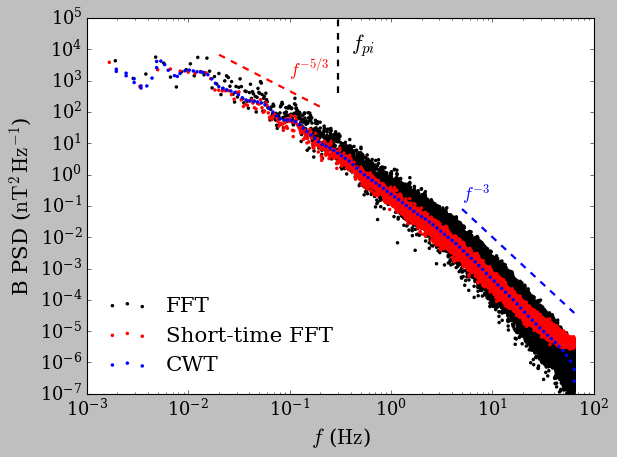

In [8]:
fig, ax = mu.plt.subplots(1, 1, figsize=(8, 6))
kw = dict(ec="none", s=10)

ax.scatter(S_fft.frequency, S_fft.pint.dequantify(), fc="k", label="FFT", **kw)
ax.scatter(S_stft.frequency, S_stft.mean("time").pint.dequantify(), fc="r", label="Short-time FFT", **kw)
ax.scatter(S_cwt.frequency, S_cwt.mean("time").pint.dequantify(), fc="b", label="CWT", **kw)

mask = (2e-2 <= f_arr) & (f_arr <= 2e-1)
ax.plot(x := f_arr[mask], y := 1e1 * f_arr[mask] ** (-5 / 3), "--r", lw=2)
ax.text(0.5 * x[-1], 1e1 * y[-1], "$f^{-5/3}$", c="r")

mask = f_arr >= 5e0
ax.plot(x := f_arr[mask], y := 1e1 * f_arr[mask] ** (-3), "--b", lw=2)
ax.text(x[0], 2 * y[0], "$f^{-3}$", c="b")

ax.axvline(3e-1, ymin=0.8, ymax=1.0, ls="--", c="k", lw=2)
ax.text(4e-1, 1e4, "$f_{pi}$", fontsize="large")

ax.set_xlim(1e-3, 1e2)
ax.set_ylim(1e-7, 1e5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(frameon=False, loc="lower left")
ax.set_xlabel(f"$f$ ({S_cwt.frequency.units:latex})")
ax.set_ylabel(f"B PSD ({S_cwt.pint.units:latex})")

fig.tight_layout()
mu.plt.show()

There is good agreement among all three methods!

#### In time-frequency domain

In time-frequency domain, the original signal and corresponding spectrograms are:

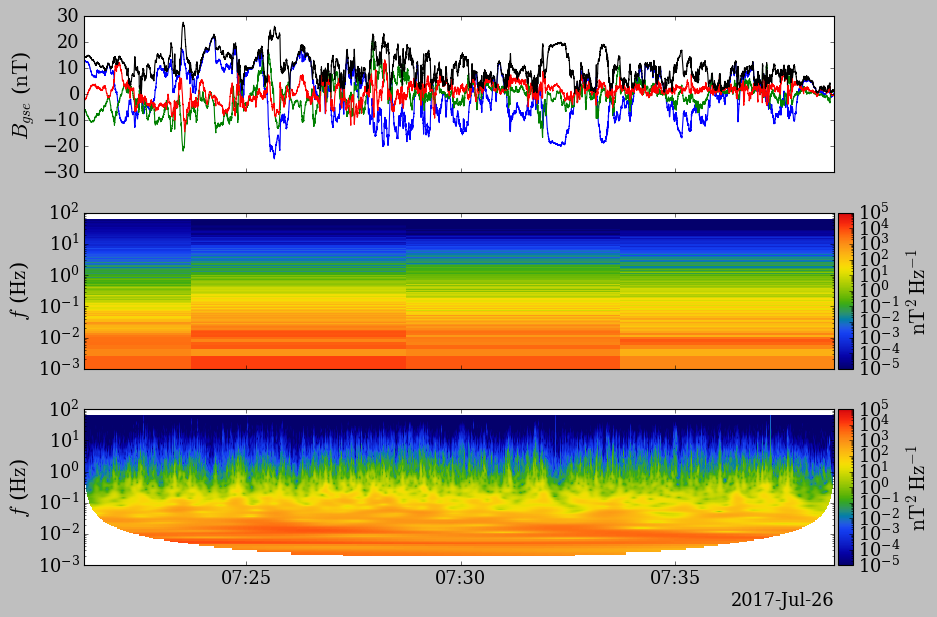

In [9]:
fig, axes = mu.plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pkw = dict(norm=mu.mplc.LogNorm(1e-5, 1e5), cmap="cet_rainbow4")

mu.add_colorbar(ax := axes[0]).remove()
ax.plot(fgm.time, Bx, "-b")
ax.plot(fgm.time, By, "-g")
ax.plot(fgm.time, Bz, "-r")
ax.plot(fgm.time, fgm.B_gse.rank_1.magnitude, "-k")
ax.set_ylabel(f"$B_{{gse}}$ ({Bx.pint.units:latex})")

cax = mu.add_colorbar(ax := axes[1])
im = ax.pcolormesh(
    *np.meshgrid(S_stft.time, S_stft.frequency, indexing="ij"),
    S_stft.transpose("time", "frequency").pint.dequantify(),
    **pkw,
)
cb = fig.colorbar(im, cax=cax)
cb.set_label(f"{S_stft.pint.units:latex}")

cax = mu.add_colorbar(ax := axes[2])
im = ax.pcolormesh(
    *np.meshgrid(S_cwt.time, S_cwt.frequency, indexing="ij"),
    S_cwt.transpose("time", "frequency").pint.dequantify(),
    **pkw,
)
cb = fig.colorbar(im, cax=cax)
cb.set_label(f"{S_cwt.pint.units:latex}")

for (i, ax) in enumerate(axes):
    mu.format_datetime_labels(ax)
    ax.set_xlim(fgm.time[0], fgm.time[-1])
    if i > 0:
        ax.set_yscale("log")
        ax.set_ylim(1e-3, 1e2)
        ax.set_ylabel(f"$f$ ({S_cwt.frequency.units:latex})")

fig.tight_layout()
mu.plt.show()

It is expected that we will lose time resolution in favor of frequency resolution in the short-time Fourier spectrum in the second panel. The continuous wavelet transform instead provides better detail in both time and frequency resolution.

### Signal reconstruction

We can also reconstruct the signals from the CWT spectra. The `xr_icwt` function uses metadata in the attributes to restore the original signal:

In [10]:
from mmspy.computation.time_frequency import xr_icwt

Bx_reconstructed = xr_icwt(Sx_cwt)
By_reconstructed = xr_icwt(Sy_cwt)
Bz_reconstructed = xr_icwt(Sz_cwt)
Bx_reconstructed

Magnitude,[0.0 0.0013420937650966483 -0.004121355423204439 ... -0.00021806254459740863 5.6364013591896635e-05 0.0]
Units,nanotesla


We can now compare the original and reconstructed signals:

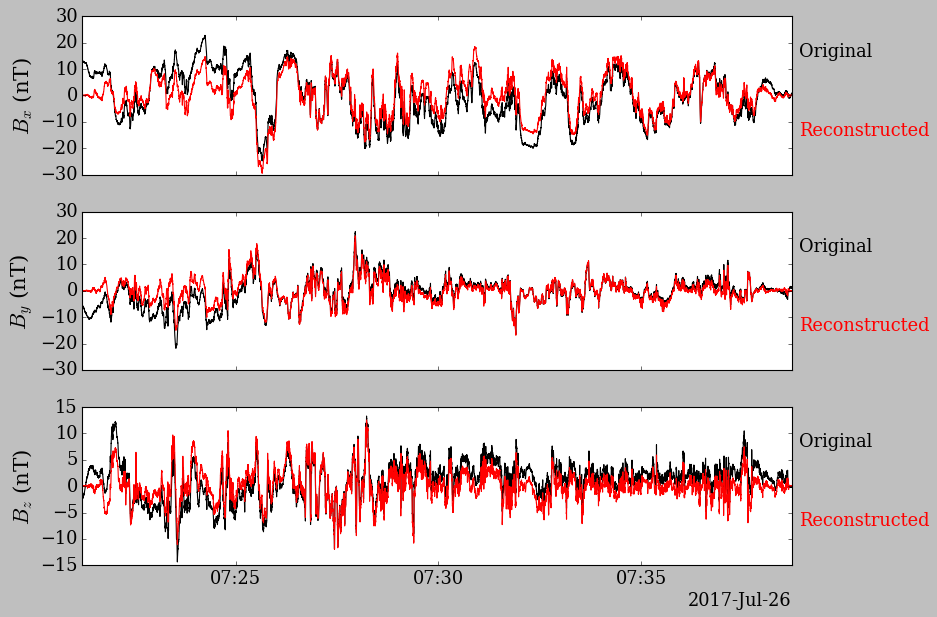

In [12]:
fig, axes = mu.plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(fgm.time, Bx, "-k")
axes[0].plot(fgm.time, Bx_reconstructed, "-r")
axes[0].set_ylabel("$B_x$ (nT)")

axes[1].plot(fgm.time, By, "-k")
axes[1].plot(fgm.time, By_reconstructed, "-r")
axes[1].set_ylabel("$B_y$ (nT)")

axes[2].plot(fgm.time, Bz, "-k")
axes[2].plot(fgm.time, Bz_reconstructed, "-r")
axes[2].set_ylabel("$B_z$ (nT)")

for (i, ax) in enumerate(axes):
    ax.set_xlim(fgm.time[0], fgm.time[-1])
    mu.format_datetime_labels(ax)
    ax.text(1.01, 0.75, "Original", c="k", transform=ax.transAxes)
    ax.text(1.01, 0.25, "Reconstructed", c="r", transform=ax.transAxes)

fig.tight_layout()
mu.plt.show()

Note that since the continuous wavelet transform ignores the DC part of the spectrum, the reconstructed signals always have zero mean. In addition, due to boundary effects, the reconstruction fails at the edges. This can be mitigated by not masking out the cone of influence. However, great care is needed when interpreting the spectral density in the cone of influence.